# Calibrating the ejection criterion: when does a subhalo kick a star out of co-rotation?

This notebook calibrates the analytic ejection criterion of the paper (Sec. 3.3) against test particle simulations, and makes Figs 5 and 6 and the tables of Sec. 3.3.

**What this notebook does.**
1. It integrates a star trapped in the co-rotation resonance (the host potential and analytic bar of Sec. 3.2).
2. It runs a large Monte Carlo sweep of single subhalo fly-bys, covering:
   * mass $10^5$–$10^{10}\,{\rm M_\odot}$;
   * scale radius $r_s=f_c\,r_s^{\rm CDM}$ with $f_c\in[0.01,2]$;
   * impact parameter $b/r_s\in[10^{-2},10^{2}]$;
   * relative velocity drawn from an isotropic Maxwellian with $\sigma=200\,{\rm km\,s^{-1}}$, in all directions;
   * libration phase at the moment of the encounter.
3. For every encounter it records:
   * the **predicted** kick $\Delta I_{\rm pred}$ from the analytic impulse model (Eq. 40, relative impulse);
   * the **measured** kick $\Delta I_{\rm sim}$, from $L_z$ just after closest approach;
   * whether the star **left the resonance**, i.e. whether its slow angle, averaged over one radial period, circulates afterwards.
4. It summarises the outcome as the ejected fraction against $|\Delta I|/2\Delta I_{\rm half}$, and fits the threshold.

The candidates are resampled so that the predicted $|\Delta I|/2\Delta I_{\rm half}$ is roughly log-uniform, which puts plenty of encounters around the threshold.

With `HOST_FRAME = True`, orbits are integrated in the frame of the host. A time-dependent uniform acceleration (Agama `UniformAcceleration`) equal to minus the mean subhalo acceleration of the host mass enclosed by the orbit is added, consistent with the differential-force treatment of the analytic model.


In [1]:
import os, time, tempfile, json, shutil, warnings
import shutil
if os.path.isdir("/Library/TeX/texbin"):                         # TeX Live on macOS
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import brentq, minimize
import agama

rcParams.update({
    "text.usetex": shutil.which("latex") is not None,   # falls back to mathtext if no LaTeX is installed
    "font.family": "serif", "font.serif": ["Computer Modern"],
    "axes.labelsize": 14, "font.size": 13, "legend.fontsize": 11,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"
})
agama.setUnits(mass=1, length=1, velocity=1)   # time unit = kpc/(km/s) = 0.978 Gyr
G = 4.300917e-6


## Settings

In [2]:
BAR        = 'hamilton'    # 'hamilton': analytic Chiba et al. (2021) bar with A = 0.02 (same bar as the analytic model)
                           # 'ferrers' : a Ferrers bar (weaker m=2 term)
HOST_FRAME = True          # integrate in the host frame (differential force) and predict with Delta v_rel
DV_LIST    = [5.0, 25.0]   # initial velocity offsets [km/s] -> small and larger libration amplitude
N_ENC      = 5000          # target number of encounters per libration amplitude
SIGMA      = 200.          # subhalo velocity dispersion [km/s]
LOGM_RANGE = (5.0, 10.0)   # log10 subhalo mass
FC_RANGE   = (0.01, 2.0)   # r_s / r_s^CDM, sampled log-uniformly
B_RANGE    = (0.01, 100.)   # b / r_s, sampled log-uniformly
SEED       = 42
RERUN      = False         # False: load the saved results in ../data instead of re-running the sweep
TAG        = ''            # appended to the output file names so that runs with different settings do not overwrite each other
OUTFILE    = f"../data/ejection_calibration_{BAR}_{'host' if HOST_FRAME else 'fixed'}{TAG}.npz"
# resampling design: the candidates are resampled to be log-uniform in predicted |dI|/2dI_half over X_LOGRANGE
X_LOGRANGE, N_XBINS, POOL_FACTOR_MAX = (-2.5, 1.0), 35, 400   # POOL_FACTOR_MAX: give up drawing after this many candidates per requested encounter

v0, r_core, omega_p, m_res = 230., 0.1, 35., 2
rng = np.random.default_rng(SEED)

# ---- validate the settings early, with readable messages
assert BAR in ('hamilton', 'ferrers'), "BAR must be 'hamilton' or 'ferrers'"
assert len(DV_LIST) >= 1, "DV_LIST needs at least one initial velocity offset"
for _n, _r, _pos in [('LOGM_RANGE', LOGM_RANGE, False), ('FC_RANGE', FC_RANGE, True), ('B_RANGE', B_RANGE, True)]:
    assert len(_r) == 2 and _r[0] <= _r[1], f"{_n} must be (low, high) with low <= high"
    assert (not _pos) or _r[0] > 0, f"{_n} is sampled log-uniformly, so it must be positive"
assert N_ENC >= N_XBINS, f"N_ENC must be at least N_XBINS = {N_XBINS}"
SETTINGS = dict(BAR=BAR, HOST_FRAME=HOST_FRAME, DV_LIST=[float(d) for d in DV_LIST], N_ENC=N_ENC, SIGMA=SIGMA, LOGM_RANGE=list(LOGM_RANGE),
                FC_RANGE=list(FC_RANGE), B_RANGE=list(B_RANGE), SEED=SEED, X_LOGRANGE=list(X_LOGRANGE), N_XBINS=N_XBINS,
                EJ_TEST='psi averaged over one radial period')   # saved sweeps made with the old (instantaneous psi) test do not match


## Host potential and bar

In [3]:
halo  = agama.Potential(type='Logarithmic', v0=v0, scaleRadius=r_core)
R_CR0 = v0/omega_p

def hamilton_bar_static(xyz, A_bar=0.02, b_bar=0.28, z_b=1.0):
    """Chiba, Friske & Schoenrich (2021) bar at t = 0 (major axis along x)."""
    R = np.hypot(xyz[:,0], xyz[:,1]); phi = np.arctan2(xyz[:,1], xyz[:,0]); z = xyz[:,2]; s = R/R_CR0
    return -A_bar*v0**2/2*np.cos(2*phi)*s**2*((b_bar+1)/(b_bar+s))**5*np.exp(-z**2/(2*z_b**2))

if BAR == 'hamilton':
    # expand the python potential on a CylSpline grid so that orbit integration runs in C++
    bar_static = agama.Potential(type='CylSpline', potential=agama.Potential(hamilton_bar_static, symmetry='bisymmetric'),
                                 mmax=4, symmetry='bisymmetric', gridSizeR=50, gridSizez=30,
                                 Rmin=0.05, Rmax=60, zmin=0.05, zmax=20)
elif BAR == 'ferrers':
    bar_static = agama.Potential(type='Ferrers', mass=10**9.15, scaleRadius=3.5, axisRatioY=1.4/3.5, axisRatioZ=1.0/3.5)
static = agama.Potential(halo, bar_static)


## Resonance properties (pendulum model)

$\epsilon$ is the cosine amplitude of the $m=2$ term at co-rotation, and $\alpha=|d\omega_{\rm res}/dI|=m\,|d\omega_{\rm res}/dL_z|$. The half-width is $\Delta I_{\rm half}=2\sqrt{\epsilon/\alpha}$ (Eq. 30), and the full width $2\Delta I_{\rm half}$ is the unit used throughout.

In [4]:
def vc_axi(R, pot):
    ph = np.linspace(0, 2*np.pi, 128, endpoint=False)
    F  = pot.force(np.column_stack([R*np.cos(ph), R*np.sin(ph), 0*ph]))
    return np.sqrt(-R*np.sum(F[:, :2]*np.column_stack([np.cos(ph), np.sin(ph)]), 1).mean())

R_res = brentq(lambda R: vc_axi(R, static)/R - omega_p, 0.25*R_CR0, 4*R_CR0)
ph    = np.linspace(0, 2*np.pi, 256, endpoint=False)
Phi   = static.potential(np.column_stack([R_res*np.cos(ph), R_res*np.sin(ph), 0*ph]))
eps   = 2*abs(np.mean((Phi - Phi.mean())*np.exp(-2j*ph)))
dR    = 1e-3*R_res
w_res = lambda R: m_res*(vc_axi(R, static)/R - omega_p)
L_of  = lambda R: R*vc_axi(R, static)
alpha = m_res*abs((w_res(R_res+dR) - w_res(R_res-dR))/(L_of(R_res+dR) - L_of(R_res-dR)))
dI_half = 2*np.sqrt(eps/alpha); W = 2*dI_half
T_lib   = 2*np.pi/np.sqrt(alpha*eps)
print(f"BAR = {BAR}: R_res = {R_res:.3f} kpc, eps = {eps:.3g} (km/s)^2, alpha = {alpha:.4g} kpc^-2")
print(f"Delta I_half = {dI_half:.3g} kpc km/s  (Delta L_z,half = {m_res*dI_half:.3g}),  T_lib = {T_lib*0.9778:.3g} Gyr")

# time grid: encounters over ~2.5 libration periods, followed for 3.5 libration periods
DT = 0.002
T_PRE, T_POST = 0.3, 3.5*T_lib
T_ENC_MIN, T_ENC_MAX = 0.5, 0.5 + 2.5*T_lib
t_grid = np.arange(0, T_ENC_MAX + T_POST + 0.05 + DT, DT)
bar = agama.Potential(potential=bar_static, rotation=np.column_stack([t_grid, omega_p*t_grid]))
pot = agama.Potential(halo, bar)


BAR = hamilton: R_res = 6.571 kpc, eps = 529 (km/s)^2, alpha = 0.09261 kpc^-2
Delta I_half = 151 kpc km/s  (Delta L_z,half = 302),  T_lib = 0.878 Gyr


## Encounter machinery

* **Star.** The unperturbed resonant orbit is integrated once for each libration amplitude. The pendulum state at the encounter comes from the guiding centre, smoothed over one radial period: $I_0=(L_z-\langle L_z\rangle)/m$ and $\phi_0=\psi-\pi$, so the stable point sits at $\phi_0=0$.
* **Subhalo.** A Plummer sphere on a straight line in the inertial frame, $\mathbf x_{\rm sh}(t)=\mathbf x_\star(t_{\rm enc})+\mathbf b+\mathbf w\,(t-t_{\rm enc})$, with $\mathbf b\perp\mathbf u$ and $\mathbf u=\mathbf w-\mathbf v_\star$.
* **Host frame.** An acceleration $-\langle \mathbf a_{\rm sh}(\mathbf y,t)\rangle_y$ is added, where $\mathbf y$ samples the enclosed host mass (uniform in radius within $R_\star$, held fixed).
* **Outputs.**
  * $\Delta I_{\rm pred}$: the analytic relative impulse (Sec. 3.1).
  * $\Delta I_{\rm sim}$: $[L_z^{\rm pert}-L_z^{\rm unpert}]/m$, measured at $t_{\rm enc}+\delta t$, with $\delta t = 4(b+r_s)/u$ clipped to $[0.01, 0.05]$.
  * **ejected**: whether the slow angle $\psi=m(\varphi-\Omega_{\rm p}t)$, averaged over one radial period, spans more than $2\pi$ after the encounter. The average removes the epicyclic swing of $\varphi$. Without it, a star thrown onto an eccentric orbit that still librates is counted as ejected (about 5 per cent of the ejections in this sweep, all of them violent encounters).


In [5]:
def _fib(n):
    i = np.arange(n) + 0.5; th = np.arccos(1 - 2*i/n); p = np.pi*(1 + 5**0.5)*i
    return np.stack([np.sin(th)*np.cos(p), np.sin(th)*np.sin(p), np.cos(th)], 1)
NY = 40
Y_UNIT = ((np.arange(NY) + 0.5)/NY)[:, None]*_fib(NY)[rng.permutation(NY)]   # enclosed-mass sample (radius units)

def star_orbit(dv):
    ic = np.array([0, R_res, 0, -(vc_axi(R_res, static) + dv), 0, 0])     # stable Lagrange point (bar minor axis)
    tt, xv = agama.orbit(potential=pot, ic=ic, time=t_grid[-1], trajsize=len(t_grid), dtype=float)
    Lz  = xv[:,0]*xv[:,4] - xv[:,1]*xv[:,3]
    psi = m_res*(np.unwrap(np.arctan2(xv[:,1], xv[:,0])) - omega_p*tt)
    k   = int(round(2*np.pi/(np.sqrt(2)*omega_p)/DT)); ker = np.ones(k)/k     # one radial period
    psi_s, Lz_s = np.convolve(psi, ker, mode='same'), np.convolve(Lz, ker, mode='same')
    Lz_c = Lz_s[k:-k].mean()
    amp  = (Lz_s[k:-k].max() - Lz_s[k:-k].min())/2/m_res/dI_half
    return dict(tt=tt, xv=xv, Lz=Lz, psi_s=psi_s, Lz_s=Lz_s, Lz_c=Lz_c, amp=amp)

def _dv_point(bvec, u, M, rs):
    return 2*G*M/u*bvec/(np.sum(bvec**2, -1, keepdims=True) + rs**2)

def predict_dI(x_star, bvec, uvec, M, rs, host=HOST_FRAME):
    """Analytic slow-action kick: (R/m) e_phi . Delta v_rel  (Delta v if host=False)."""
    u = np.linalg.norm(uvec); uh = uvec/u
    dv = _dv_point(bvec, u, M, rs)
    Rst = np.hypot(x_star[0], x_star[1])
    if host:
        s  = x_star + bvec - Y_UNIT*Rst
        dv = dv - _dv_point(s - (s @ uh)[:, None]*uh, u, M, rs).mean(0)
    ph_ = np.arctan2(x_star[1], x_star[0])
    return Rst/m_res*(dv @ np.array([-np.sin(ph_), np.cos(ph_), 0]))

def draw_candidate(star, logm_range=None, b_abs=None):
    """Random encounter. logm_range / b_abs (absolute b in kpc, log-uniform) override the global settings when given."""
    M  = 10**rng.uniform(*(logm_range or LOGM_RANGE))
    rs = 10**rng.uniform(*np.log10(FC_RANGE))*1.62*(M/1e8)**0.5
    b  = 10**rng.uniform(*np.log10(b_abs)) if b_abs is not None else rs*10**rng.uniform(*np.log10(B_RANGE))
    ie = rng.integers(int(T_ENC_MIN/DT), int(T_ENC_MAX/DT))
    w  = rng.normal(0, SIGMA, 3)
    uvec = w - star['xv'][ie, 3:]; uh = uvec/np.linalg.norm(uvec)
    e  = rng.normal(size=3); e -= (e @ uh)*uh; e /= np.linalg.norm(e)
    return dict(M=M, rs=rs, b=b, bvec=b*e, ie=ie, w=w, uvec=uvec, u=np.linalg.norm(uvec))

def simulate(c, star, host=HOST_FRAME):
    tt, xv = star['tt'], star['xv']
    i0 = c['ie'] - int(T_PRE/DT); ts = tt[i0:c['ie'] + int(T_POST/DT) + 1]
    t_enc, x_enc = tt[c['ie']], xv[c['ie'], :3] + c['bvec']
    xsh  = x_enc[None, :] + (ts - t_enc)[:, None]*c['w'][None, :]
    comps = [pot, agama.Potential(type='Plummer', mass=c['M'], scaleRadius=c['rs'], center=np.column_stack([ts, xsh]))]
    if host:
        Rst = np.hypot(*xv[c['ie'], :2]); Y = Y_UNIT*Rst
        tau = (c['b'] + c['rs'] + Rst)/c['u']
        tn  = t_enc + tau*np.sinh(np.linspace(-np.arcsinh(T_PRE/tau), np.arcsinh(T_POST/tau), 1500))
        d   = Y[None] - (x_enc[None, :] + (tn - t_enc)[:, None]*c['w'][None, :])[:, None, :]
        A   = (-G*c['M']*d/(np.sum(d**2, -1, keepdims=True) + c['rs']**2)**1.5).mean(1)
        fn  = os.path.join(tempfile.gettempdir(), f"hostacc_{os.getpid()}.txt")
        np.savetxt(fn, np.column_stack([tn, -A]))                 # fictitious acceleration of the host frame
        comps.append(agama.Potential(type='UniformAcceleration', file=fn))
    _, xp = agama.orbit(potential=agama.Potential(*comps), ic=xv[i0], timestart=tt[i0],
                        time=ts[-1] - ts[0], trajsize=len(ts), dtype=float)
    return ts, xp, c['ie'] - i0


## Run the sweep

In [6]:
COLS = ['dv', 'amp', 'logM', 'rs', 'b', 'u', 'x_pred', 'x_sim', 'x_sim_f2', 'x_sim_f8', 'x_sim_25', 'I0', 'phi0', 'ejected']

# times after closest approach at which the kick is measured: factor * (b + r_s)/u, clipped (time units)
DT_MEAS = {'x_sim': (4, 0.01, 0.05), 'x_sim_f2': (2, 0.005, 0.1), 'x_sim_f8': (8, 0.005, 0.1), 'x_sim_25': (None, 0.025/0.9778, None)}
T_EJ_START = 0.1   # the outcome is judged from t_enc + 0.1 (~100 Myr) onwards, independent of the choice above

def _k_meas(c, spec, i_rel):
    f, lo, hi = spec
    dt = lo if f is None else min(max(f*(c['b'] + c['rs'])/c['u'], lo), hi)
    return i_rel + int(round(dt/DT))

def _row(c, star, dv):
    ie = c['ie']
    ts, xp, i_rel = simulate(c, star)
    Lzp  = xp[:, 0]*xp[:, 4] - xp[:, 1]*xp[:, 3]
    x_sims = []
    for key in ['x_sim', 'x_sim_f2', 'x_sim_f8', 'x_sim_25']:
        k_m = _k_meas(c, DT_MEAS[key], i_rel)
        x_sims.append((Lzp[k_m] - star['Lz'][ie - i_rel + k_m])/m_res/W)
    psip = m_res*(np.unwrap(np.arctan2(xp[:, 1], xp[:, 0])) - omega_p*ts)
    k_R  = int(round(2*np.pi/(np.sqrt(2)*omega_p)/DT))                   # one radial period, as in star_orbit
    psip = np.convolve(psip, np.ones(k_R)/k_R, mode='valid')               # average out the epicyclic swing of phi
    ejected = np.ptp(psip[i_rel + int(round(T_EJ_START/DT)):]) > 2*np.pi
    dI_pred = predict_dI(star['xv'][ie, :3], c['bvec'], c['uvec'], c['M'], c['rs'])
    I0, phi0 = (star['Lz_s'][ie] - star['Lz_c'])/m_res, np.angle(np.exp(1j*(star['psi_s'][ie] - np.pi)))
    return [dv, star['amp'], np.log10(c['M']), c['rs'], c['b'], c['u'], dI_pred/W, *x_sims, I0/W, phi0, ejected]

def run_sweep(dv_list, n_enc, logm_range=None, b_abs=None):
    """Monte Carlo sweep of single fly-bys, resampled to be log-uniform in the predicted kick.
    logm_range, b_abs (absolute impact parameter range in kpc) override LOGM_RANGE and B_RANGE (b/r_s) if given."""
    rows, t0 = [], time.time()
    edges, quota = np.linspace(*X_LOGRANGE, N_XBINS + 1), n_enc//N_XBINS
    for dv in dv_list:
        star = star_orbit(dv)
        print(f"dv = {dv}: libration amplitude = {star['amp']:.2f} Delta I_half" + ("   (WARNING: star starts outside the separatrix)" if star['amp'] > 1 else ""))
        pool, xpp = [], np.zeros(0)
        while True:     # draw candidates until every reachable bin of predicted kick has its quota (or the pool limit is reached)
            new = [draw_candidate(star, logm_range, b_abs) for _ in range(10*n_enc)]
            pool += new
            xpp = np.concatenate([xpp, [abs(predict_dI(star['xv'][c['ie'], :3], c['bvec'], c['uvec'], c['M'], c['rs']))/W for c in new]])
            lab = np.digitize(np.log10(xpp + 1e-30), edges) - 1
            counts = np.bincount(lab[(lab >= 0) & (lab < N_XBINS)], minlength=N_XBINS)
            if not (((counts > 0) & (counts < quota)).any() and len(pool) < POOL_FACTOR_MAX*n_enc): break
        keep = [rng.choice(np.where(lab == k)[0], size=min(counts[k], quota), replace=False) for k in range(N_XBINS) if counts[k] > 0]
        if not keep: raise RuntimeError(f"no candidate has a predicted kick inside 10^{X_LOGRANGE[0]}..10^{X_LOGRANGE[1]} x 2 dI_half; check the mass / b / r_s ranges")
        keep = np.concatenate(keep)
        short = [k for k in range(N_XBINS) if counts[k] < quota]
        if short: print(f"   note: {len(short)} of {N_XBINS} bins of predicted kick are under-filled (x = 10^{edges[short[0]]:.1f}..10^{edges[short[-1]+1]:.1f}), "
                        f"so only {len(keep)} of {n_enc} encounters are run; this sweep is not log-uniform in x there")
        for j in keep: rows.append(_row(pool[j], star, dv))
        print(f"   {len(keep)} encounters from a pool of {len(pool)}, {time.time() - t0:.0f} s elapsed")
    return np.array(rows, float)

def load_or_run(outfile, signature, rerun, runner):
    """Load a saved sweep if it exists and was made with the same settings, otherwise run it and save it."""
    if not rerun and os.path.exists(outfile):
        d = np.load(outfile); meta = str(d['meta']) if 'meta' in d.files else None
        if list(d['cols']) == COLS and (meta is None or meta == signature):
            if meta is None: print(f"note: {outfile} has no recorded settings, so it cannot be checked against the settings above")
            return d['res']
        print(f"{outfile} was made with different settings (or columns): re-running")
    res = runner()
    np.savez(outfile, res=res, cols=COLS, W=W, eps=eps, alpha=alpha, meta=signature)
    return res

SIGNATURE = json.dumps({**SETTINGS, 'W': round(float(W), 3)}, sort_keys=True)
res = load_or_run(OUTFILE, SIGNATURE, RERUN, lambda: run_sweep(DV_LIST, N_ENC))
R = {k: res[:, i] for i, k in enumerate(COLS)}; R['ejected'] = R['ejected'].astype(bool)
print(res.shape)


(9884, 14)


## Calibration

We fit $P_{\rm ej}(x)=p_{\max}/\{1+\exp[-\ln(x/x_{50})/w]\}$ to the outcomes, with $x=|\Delta I|/2\Delta I_{\rm half}$ taken either from the prediction or from the measured kick.

The pendulum criterion predicts escape when $K=\tfrac12\alpha(I_0+\Delta I)^2-\epsilon\cos\phi_0>\epsilon$. For a star at the centre of the resonance this reduces to $x>0.5$, the paper's $\Delta I_{\rm sh}>\Delta I_{\rm half}$.


In [7]:
def fit_logistic(x, y, min_class=5):
    """Maximum-likelihood logistic fit; returns (nan, nan, nan) if fewer than min_class encounters are ejected / trapped."""
    y = np.asarray(y, bool)
    if y.sum() < min_class or (~y).sum() < min_class: return np.nan, np.nan, np.nan
    lx = np.log(np.abs(x) + 1e-12)
    def nll(p):
        lx50, lw, lp = p; P = (1/(1 + np.exp(-lp)))/(1 + np.exp(-(lx - lx50)/np.exp(lw)))
        P = np.clip(P, 1e-9, 1 - 1e-9); return -np.sum(y*np.log(P) + (1 - y)*np.log(1 - P))
    best = None
    with np.errstate(all='ignore'):
        for p0 in ([np.log(0.5), np.log(0.5), 3.0], [np.log(0.3), np.log(0.3), 2.0], [0.0, np.log(0.8), 4.0]):    # several starts: the likelihood is not convex
            r = minimize(nll, p0, method='Nelder-Mead', options=dict(maxiter=6000, xatol=1e-7, fatol=1e-10))
            if best is None or r.fun < best.fun: best = r
    lx50, lw, lp = best.x
    return np.exp(lx50), np.exp(lw), 1/(1 + np.exp(-lp))

def pendulum_ejected(I0, phi0, x):
    """Pendulum criterion in units of W = 2 Delta I_half: K > eps  <=>  (I0 + x)^2/(1/4) - ... ."""
    return 0.5*alpha*((I0 + x)*W)**2 - eps*np.cos(phi0) > eps

fits = {}
print(f"{'amplitude':>10s} {'kick':>9s} {'x_50':>7s} {'width':>7s} {'p_max':>6s}   accuracy: x>0.5   x>x_50   pendulum")
for dv in DV_LIST:
    s = R['dv'] == dv; y = R['ejected'][s]
    for kick in ['x_pred', 'x_sim']:
        x = R[kick][s]; x50, w_, pm = fit_logistic(x, y); fits[(dv, kick)] = (x50, w_, pm)
        acc_n = np.mean((np.abs(x) > 0.5) == y); acc_c = np.mean((np.abs(x) > x50) == y)
        acc_p = np.mean(pendulum_ejected(R['I0'][s], R['phi0'][s], x) == y)
        print(f"{R['amp'][s][0]:10.2f} {kick:>9s} {x50:7.3f} {w_:7.3f} {pm:6.2f}   {acc_n:14.3f} {acc_c:8.3f} {acc_p:10.3f}")


 amplitude      kick    x_50   width  p_max   accuracy: x>0.5   x>x_50   pendulum
      0.21    x_pred   0.429   0.507   0.81            0.868    0.865      0.870
      0.21     x_sim   0.369   0.580   1.00            0.873    0.875      0.878
      0.69    x_pred   0.290   0.708   0.83            0.823    0.829      0.855


      0.69     x_sim   0.283   0.741   1.00            0.811    0.834      0.874


## Figure: when does a star leave the resonance?

* **Left panel.** Fraction of encounters that eject the star, against the kick in units of the full resonance width. Solid lines use the predicted kick and dashed lines the kick measured in the simulation. The dotted line marks $\Delta I = \Delta I_{\rm half}$ (Eq. 31).
* **Middle panel.** Measured against predicted kick, coloured by relative speed. Slow encounters ($u\lesssim150\,{\rm km\,s^{-1}}$) are no longer impulsive, so the kick they deliver falls below the prediction.
* **Right panel.** Median ratio of measured to predicted kick against relative speed, for each mass bin (star near the resonance centre; bands show the 16th–84th percentiles). This summarises where the impulse approximation holds, which is the content of the old Table 2.


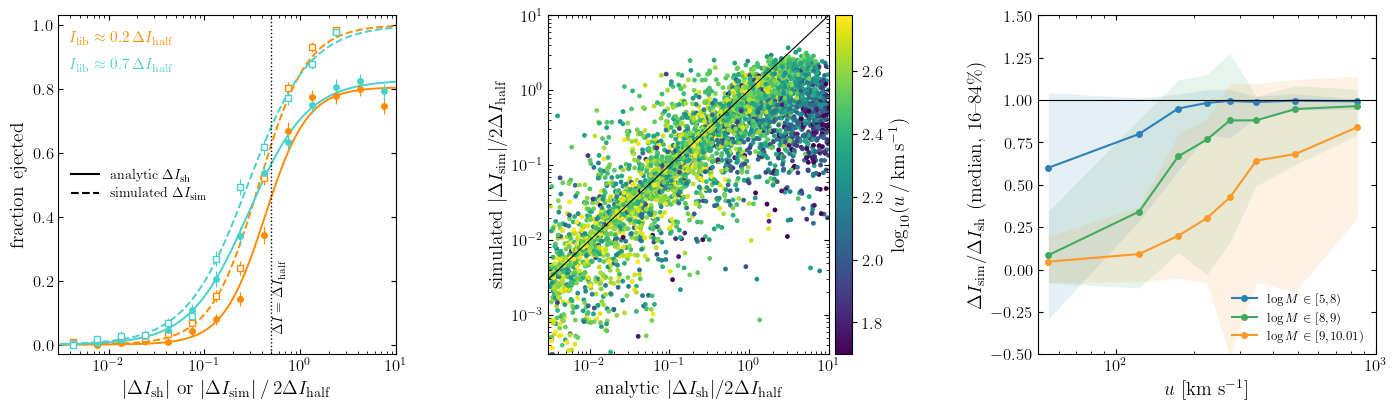

In [8]:
amp_colors = ['darkorange', 'mediumturquoise', 'magenta', 'tab:blue', 'tab:green', 'tab:brown']
bins = np.logspace(-2.5, 1, 15); xc = np.sqrt(bins[1:]*bins[:-1]); xs_f = np.logspace(-2.5, 1, 300)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.4), gridspec_kw={'wspace': 0.45})
for axis in (ax1, ax2, ax3):
    axis.set_xscale('log'); axis.tick_params(axis='both', which='both', direction='in', top=True, right=True)

for k, dv in enumerate(DV_LIST):
    s = R['dv'] == dv; col = amp_colors[k]
    for kick, ls, mk in [('x_pred', '-', 'o'), ('x_sim', '--', 's')]:
        x = np.abs(R[kick][s]); y = R['ejected'][s]
        n = np.histogram(x, bins)[0]; ne = np.histogram(x[y], bins)[0]; ok = n > 4
        f = ne[ok]/n[ok]; err = np.sqrt(f*(1 - f)/n[ok] + 1e-4)
        ax1.errorbar(xc[ok], f, yerr=err, fmt=mk, ms=4, color=col, mfc='white' if kick == 'x_sim' else col, lw=0.8, capsize=0)
        x50, w_, pm = fits[(dv, kick)]
        ax1.plot(xs_f, pm/(1 + np.exp(-np.log(xs_f/x50)/w_)), ls=ls, color=col, lw=1.4)
    ax1.text(0.03, 0.92 - 0.08*k, r'$I_{\rm lib} \approx %.1f\,\Delta I_{\rm half}$' % R['amp'][s][0],
             transform=ax1.transAxes, color=col, fontsize=11)
ax1.axvline(0.5, color='k', ls=':', lw=1)
ax1.text(0.52, 0.03, r'$\Delta I = \Delta I_{\rm half}$', fontsize=10, rotation=90, va='bottom')
ax1.plot([], [], 'k-', label=r'analytic $\Delta I_{\rm sh}$'); ax1.plot([], [], 'k--', label=r'simulated $\Delta I_{\rm sim}$')
ax1.legend(loc='center left', frameon=False, fontsize=10)
ax1.set_xlim(3e-3, 10); ax1.set_ylim(-0.03, 1.03)
ax1.set_xlabel(r'$|\Delta I_{\rm sh}|$ or $|\Delta I_{\rm sim}|\,/\,2\Delta I_{\rm half}$'); ax1.set_ylabel(r'fraction ejected')

s = R['dv'] == DV_LIST[0]
sc = ax2.scatter(np.abs(R['x_pred'][s]), np.abs(R['x_sim'][s]), c=np.log10(R['u'][s]), s=6, cmap='viridis',
                 vmin=np.log10(50), vmax=np.log10(600), rasterized=True)
ax2.plot([1e-3, 20], [1e-3, 20], 'k-', lw=0.8)
ax2.set_yscale('log'); ax2.set_xlim(3e-3, 10); ax2.set_ylim(3e-4, 10)
ax2.set_xlabel(r'analytic $|\Delta I_{\rm sh}| / 2\Delta I_{\rm half}$'); ax2.set_ylabel(r'simulated $|\Delta I_{\rm sim}| / 2\Delta I_{\rm half}$')
cb = fig.colorbar(sc, ax=ax2, pad=0.02); cb.set_label(r'$\log_{10}(u\,/\,{\rm km\,s^{-1}})$')

# (c) where the impulse approximation holds: median measured/predicted kick vs relative speed, per mass bin
_e = sorted(set([LOGM_RANGE[0]] + [e for e in (8, 9, 10, 11) if LOGM_RANGE[0] < e < LOGM_RANGE[1]])) + [LOGM_RANGE[1] + 0.01]
MASS_BINS = list(zip(_e[:-1], _e[1:]))      # adapts to LOGM_RANGE so that no bin is empty
mass_cols = ['#2c7fb8', '#41ab5d', '#fe9929', '#d7301f', '#756bb1', '#636363']
ub = np.array([30, 100, 150, 200, 250, 300, 400, 600, 1200])
s0 = (R['dv'] == DV_LIST[0]) & (np.abs(R['x_pred']) > 0.01)
for (lo, hi), col in zip(MASS_BINS, mass_cols):
    med, q16, q84, uc = [], [], [], []
    for a, b_ in zip(ub[:-1], ub[1:]):
        m = s0 & (R['logM'] >= lo) & (R['logM'] < hi) & (R['u'] >= a) & (R['u'] < b_)
        if m.sum() >= 8:
            rat = R['x_sim'][m]/R['x_pred'][m]
            med.append(np.median(rat)); q16.append(np.percentile(rat, 16)); q84.append(np.percentile(rat, 84)); uc.append(np.sqrt(a*b_))
    if uc:
        ax3.plot(uc, med, '-o', ms=4, color=col, label=r'$\log M \in [%g, %g)$' % (lo, hi))
        ax3.fill_between(uc, q16, q84, color=col, alpha=0.12, lw=0)
ax3.axhline(1, color='k', lw=0.8)
ax3.set_xlim(50, 1000); ax3.set_ylim(-0.5, 1.5)
ax3.set_xlabel(r'$u$ [km s$^{-1}$]'); ax3.set_ylabel(r'$\Delta I_{\rm sim}/\Delta I_{\rm sh}$ (median, 16--84\%)')
ax3.legend(loc='lower right', frameon=False, fontsize=9)

#plt.savefig('../figures/ejection_calibration.pdf', dpi=400, bbox_inches='tight')   # exploratory; the paper version is made at the end
plt.show()


## Table: accuracy of the impulse model

For each mass bin the table gives:
* the median and 16th–84th percentiles of $\Delta I_{\rm sim}/\Delta I_{\rm sh}$;
* the coefficient of determination of $\log|\Delta I|$;
* the fraction of encounters whose outcome (ejected or not) is predicted correctly by $|\Delta I_{\rm sh}|>\Delta I_{\rm half}$, for both libration amplitudes.

The ensemble deliberately oversamples concentrated subhaloes and kicks near the threshold, so the "near-CDM" row, $r_s>0.5\,r_s^{\rm CDM}$, is listed separately. The version of this table used in the paper (`table_calibration.tex`) is written by the cells at the end of the notebook.


In [9]:
def stats(m):
    g = m & (np.abs(R['x_pred']) > 0.01)
    if g.sum() < 3: return m.sum(), np.nan, np.nan, np.nan, np.nan
    rat = R['x_sim'][g]/R['x_pred'][g]
    lr, lp = np.log10(np.abs(R['x_sim'][g]) + 1e-12), np.log10(np.abs(R['x_pred'][g]))
    r2 = 1 - np.sum((lr - lp)**2)/np.sum((lr - lr.mean())**2)
    return m.sum(), np.median(rat), np.percentile(rat, 16), np.percentile(rat, 84), r2

def accuracy(m):
    return np.mean((np.abs(R['x_pred'][m]) > 0.5) == R['ejected'][m]) if m.any() else np.nan

fc_all = R['rs']/(1.62*(10**R['logM']/1e8)**0.5)
rows_def = [(r'$%g$--$%g$' % (lo, min(hi, np.floor(LOGM_RANGE[1]*100)/100 if hi > LOGM_RANGE[1] else hi)), lambda s, lo=lo, hi=hi: s & (R['logM'] >= lo) & (R['logM'] < hi)) for lo, hi in MASS_BINS]
rows_def += [(r'near-CDM $r_s$', lambda s: s & (fc_all > 0.5)), (r'all', lambda s: s)]

s_dv = [R['dv'] == dv for dv in DV_LIST]; amps = [R['amp'][s][0] for s in s_dv]
_a = ['%.1f' % a for a in amps]; amp_str = _a[0] if len(_a) == 1 else ', '.join(_a[:-1]) + ' and ' + _a[-1]
lines = [r"\begin{table}", r"\centering",
         r"\caption{Accuracy of the impulse model across the encounter sweep. Columns give the number of encounters, the median and 16th--84th percentiles of the simulated-to-analytic kick ratio (for $|\Delta I_{\rm sh}|>0.01\times2\Delta I_{\rm half}$), and $R^2$ of $\log|\Delta I|$ (star with libration amplitude %.1f\,$\Delta I_{\rm half}$), followed by the fraction of encounters whose outcome is predicted correctly by $|\Delta I_{\rm sh}|>\Delta I_{\rm half}$ for libration amplitudes %s\,$\Delta I_{\rm half}$.}" % (amps[0], amp_str),
         r"\label{tab:calibration}", r"\begin{tabular}{l%s}" % ('c'*(3 + len(amps))), r"\hline",
         r"$\log_{10}(M/{\rm M}_\odot)$ & $N$ & $\Delta I_{\rm sim}/\Delta I_{\rm sh}$ & $R^2$ & \multicolumn{%d}{c}{outcome correct} \\" % len(amps),
         r" & & & & %s \\" % ' & '.join('%.1f' % a for a in amps), r"\hline"]
for lab, sel in rows_def:
    N, med, q16, q84, r2 = stats(sel(s_dv[0]))
    _fmt = lambda v: '--' if not np.isfinite(v) else '%.2f' % v
    lines.append((r"%s & %d & $%s_{%s}^{%s}$ & %s" % (lab, N, _fmt(med), _fmt(q16), _fmt(q84), '--' if 'near' in lab else _fmt(r2))) + ''.join(' & ' + _fmt(accuracy(sel(s))) for s in s_dv) + r" \\")
lines += [r"\hline", r"\end{tabular}", r"\end{table}"]
latex = "\n".join(lines)
print(latex)


\begin{table}
\centering
\caption{Accuracy of the impulse model across the encounter sweep. Columns give the number of encounters, the median and 16th--84th percentiles of the simulated-to-analytic kick ratio (for $|\Delta I_{\rm sh}|>0.01\times2\Delta I_{\rm half}$), and $R^2$ of $\log|\Delta I|$ (star with libration amplitude 0.2\,$\Delta I_{\rm half}$), followed by the fraction of encounters whose outcome is predicted correctly by $|\Delta I_{\rm sh}|>\Delta I_{\rm half}$ for libration amplitudes 0.2 and 0.7\,$\Delta I_{\rm half}$.}
\label{tab:calibration}
\begin{tabular}{lccccc}
\hline
$\log_{10}(M/{\rm M}_\odot)$ & $N$ & $\Delta I_{\rm sim}/\Delta I_{\rm sh}$ & $R^2$ & \multicolumn{2}{c}{outcome correct} \\
 & & & & 0.2 & 0.7 \\
\hline
$5$--$8$ & 1003 & $0.98_{0.73}^{1.04}$ & 0.66 & 0.98 & 0.96 \\
$8$--$9$ & 1149 & $0.86_{0.10}^{1.07}$ & 0.39 & 0.90 & 0.82 \\
$9$--$10$ & 2781 & $0.36_{-0.09}^{1.00}$ & 0.01 & 0.81 & 0.78 \\
near-CDM $r_s$ & 232 & $0.21_{-0.12}^{0.83}$ & -- & 1.00 &

## Robustness to the time at which the kick is measured

The ejection outcome is judged from $t_{\rm enc}+100$ Myr onwards, so it does not depend on when the kick is measured. The measured kick itself does. The table recomputes the median $\Delta I_{\rm sim}/\Delta I_{\rm sh}$ and the fitted threshold $x_{50}$ for the measured kick, for several measurement times:
* $\delta t = f\,(b+r_s)/u$ with $f=2$, 4 (default) and 8;
* a fixed $\delta t=25$ Myr, for comparison.


In [10]:
labels = {'x_sim_f2': r'2 (b+r_s)/u', 'x_sim': r'4 (b+r_s)/u (default)', 'x_sim_f8': r'8 (b+r_s)/u', 'x_sim_25': r'25 Myr (fixed)'}
print(f"{'measurement time':>24s} {'amplitude':>10s} {'median ratio':>13s} {'16-84%':>15s} {'x_50 (measured)':>16s}")
for key in ['x_sim_f2', 'x_sim', 'x_sim_f8', 'x_sim_25']:
    for dv in DV_LIST:
        s = (R['dv'] == dv); g = s & (np.abs(R['x_pred']) > 0.01)
        rat = R[key][g]/R['x_pred'][g] if g.any() else np.array([np.nan])
        x50, w_, pm = fit_logistic(R[key][s], R['ejected'][s])
        print(f"{labels[key]:>24s} {R['amp'][s][0]:10.2f} {np.nanmedian(rat):13.2f}   [{np.nanpercentile(rat,16):5.2f},{np.nanpercentile(rat,84):5.2f}] {x50:16.3f}")


        measurement time  amplitude  median ratio          16-84%  x_50 (measured)
             2 (b+r_s)/u       0.21          0.65   [-0.01, 1.03]            0.370


             2 (b+r_s)/u       0.69          0.63   [-0.00, 1.05]            0.283


   4 (b+r_s)/u (default)       0.21          0.63   [-0.02, 1.04]            0.369
   4 (b+r_s)/u (default)       0.69          0.62   [-0.03, 1.06]            0.283


             8 (b+r_s)/u       0.21          0.62   [-0.03, 1.03]            0.362


             8 (b+r_s)/u       0.69          0.61   [-0.03, 1.06]            0.281
          25 Myr (fixed)       0.21          0.64   [-0.01, 1.05]            0.371


          25 Myr (fixed)       0.69          0.62   [-0.02, 1.08]            0.284


## Impact parameter and velocity impulse

Two more views of where the impulse approximation holds (star with the smaller libration amplitude):
* **Left panel.** Median measured-to-predicted kick against $b/r_s$, for each mass bin. At fixed mass the ratio depends only weakly on the impact parameter.
* **Right panel.** The same ratio against the size of the predicted velocity impulse relative to the encounter speed, $\Delta v_{\rm pred}/u$, with $\Delta v_{\rm pred}=2GMb/[u(b^2+r_s^2)]$, for both libration amplitudes. The ratio is close to a single function of $\Delta v_{\rm pred}/u$: the approximation fails when the impulse is not small compared with $u$.

The mass bins here cover the whole range of the sweep, unlike `MASS_BINS` above.

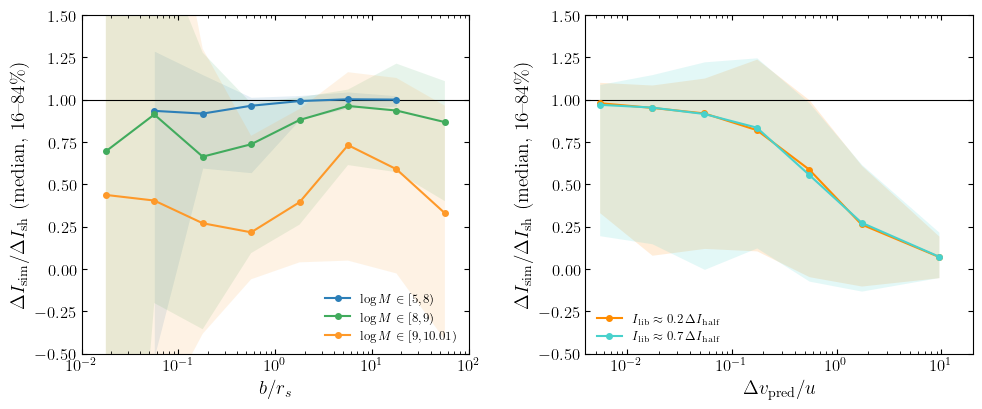

In [11]:
MB = MASS_BINS
mb_cols = ['#2c7fb8', '#41ab5d', '#fe9929', '#d7301f', '#756bb1', '#636363']
fc_all = R['rs']/(1.62*(10**R['logM']/1e8)**0.5)

def ratio_curve(sel, var, edges, nmin=8):
    # median and 16-84% of x_sim/x_pred in bins of `var`
    out = []
    for a, b_ in zip(edges[:-1], edges[1:]):
        m = sel & (var >= a) & (var < b_)
        if m.sum() >= nmin:
            rat = R['x_sim'][m]/R['x_pred'][m]; out.append((np.sqrt(a*b_), np.median(rat), np.percentile(rat, 16), np.percentile(rat, 84)))
    return np.array(out).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={'wspace': 0.3})
for axis in (ax1, ax2):
    axis.set_xscale('log'); axis.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    axis.axhline(1, color='k', lw=0.8)

s0 = (R['dv'] == DV_LIST[0]) & (np.abs(R['x_pred']) > 0.01)
for (lo, hi), col in zip(MB, mb_cols):
    t = ratio_curve(s0 & (R['logM'] >= lo) & (R['logM'] < hi), R['b']/R['rs'], np.logspace(np.log10(B_RANGE[0]), np.log10(B_RANGE[1]), 9))
    if t.size:
        ax1.plot(t[0], t[1], '-o', ms=4, color=col, label=r'$\log M \in [%g, %g)$' % (lo, hi)); ax1.fill_between(t[0], t[2], t[3], color=col, alpha=0.12, lw=0)
ax1.set_xlim(B_RANGE[0], B_RANGE[1]); ax1.set_ylim(-0.5, 1.5)
ax1.set_xlabel(r'$b/r_s$'); ax1.set_ylabel(r'$\Delta I_{\rm sim}/\Delta I_{\rm sh}$ (median, 16--84\%)'); ax1.legend(loc='lower right', frameon=False, fontsize=9)

for k, dv in enumerate(DV_LIST):
    s1 = (R['dv'] == dv) & (np.abs(R['x_pred']) > 0.01)
    q = 2*G*10**R['logM']*R['b']/(R['u']*(R['b']**2 + R['rs']**2))/R['u']      # predicted |Delta v| / u
    t = ratio_curve(s1, q, np.array([0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 30]))
    if not t.size: continue
    ax2.plot(t[0], t[1], '-o', ms=4, color=amp_colors[k], label=r'$I_{\rm lib}\approx%.1f\,\Delta I_{\rm half}$' % R['amp'][R['dv'] == dv][0])
    ax2.fill_between(t[0], t[2], t[3], color=amp_colors[k], alpha=0.15, lw=0)
ax2.set_xlim(4e-3, 20); ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel(r'$\Delta v_{\rm pred}/u$'); ax2.set_ylabel(r'$\Delta I_{\rm sim}/\Delta I_{\rm sh}$ (median, 16--84\%)'); ax2.legend(loc='lower left', frameon=False, fontsize=9)

#plt.savefig('../figures/impulse_accuracy_b_dv.pdf', dpi=400, bbox_inches='tight')
plt.show()

## Figure: ejection probability by mass, and where ejection happens

* **Left panel.** Fraction ejected against the *predicted* kick in four mass bins (smaller libration amplitude), with the fit to all masses in black. If the calibration is insensitive to mass, including the massive subhaloes for which the predicted kick is an overestimate, the bins fall on one curve.
* **Right panel.** Outcome of every encounter in the plane of subhalo mass and scale radius relative to the CDM relation (dashed line). The ensemble is resampled towards large kicks, so the density of points is not that of a realistic population.

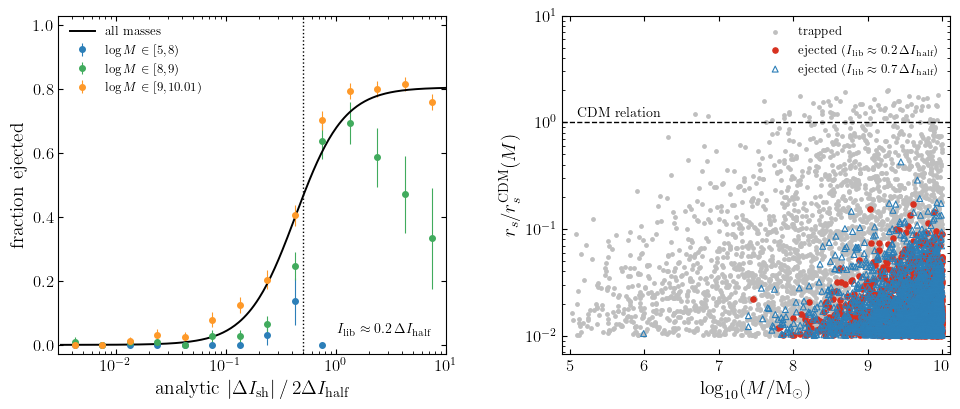

In [12]:
def frac_ejected(x, y):
    n = np.histogram(x, bins)[0]; ne = np.histogram(x[y], bins)[0]; ok = n > 4; f = ne[ok]/n[ok]
    return xc[ok], f, np.sqrt(f*(1 - f)/n[ok] + 1e-4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={'wspace': 0.3})
for axis in (ax1, ax2): axis.tick_params(axis='both', which='both', direction='in', top=True, right=True)

s = R['dv'] == DV_LIST[0]
for (lo, hi), col in zip(MB, mb_cols):
    m = (R['logM'][s] >= lo) & (R['logM'][s] < hi)
    xx, f, err = frac_ejected(np.abs(R['x_pred'][s][m]), R['ejected'][s][m])
    ax1.errorbar(xx, f, yerr=err, fmt='o', ms=4, color=col, lw=0.8, capsize=0, label=r'$\log M \in [%g, %g)$' % (lo, hi))
x50, w_, pm = fits[(DV_LIST[0], 'x_pred')]
ax1.plot(xs_f, pm/(1 + np.exp(-np.log(xs_f/x50)/w_)), 'k-', lw=1.4, label='all masses')
ax1.axvline(0.5, color='k', ls=':', lw=1)
ax1.set_xscale('log'); ax1.set_xlim(3e-3, 10); ax1.set_ylim(-0.03, 1.03)
ax1.set_xlabel(r'analytic $|\Delta I_{\rm sh}|\,/\,2\Delta I_{\rm half}$'); ax1.set_ylabel(r'fraction ejected')
ax1.legend(loc='upper left', frameon=False, fontsize=9)
ax1.text(0.96, 0.06, r'$I_{\rm lib}\approx%.1f\,\Delta I_{\rm half}$' % R['amp'][s][0], transform=ax1.transAxes, ha='right', fontsize=10)

for k, dv in enumerate(DV_LIST):
    s = R['dv'] == dv; e = R['ejected'][s]
    if k == 0:
        ax2.scatter(R['logM'][s][~e], fc_all[s][~e], s=6, c='0.75', rasterized=True, label='trapped')
        ax2.scatter(R['logM'][s][e], fc_all[s][e], s=14, c='#d7301f', rasterized=True, label=r'ejected ($I_{\rm lib}\approx%.1f\,\Delta I_{\rm half}$)' % R['amp'][s][0])
    else:
        ax2.scatter(R['logM'][s][e], fc_all[s][e], s=18, facecolors='none', edgecolors='#2c7fb8', marker='^', lw=0.8, rasterized=True,
                    label=r'ejected ($I_{\rm lib}\approx%.1f\,\Delta I_{\rm half}$)' % R['amp'][s][0])
ax2.axhline(1.0, color='k', ls='--', lw=1); ax2.text(LOGM_RANGE[0] + 0.1, 1.1, 'CDM relation', fontsize=10)
ax2.set_yscale('log'); ax2.set_xlim(LOGM_RANGE[0] - 0.1, LOGM_RANGE[1] + 0.1); ax2.set_ylim(FC_RANGE[0]/1.5, FC_RANGE[1]*5)
ax2.set_xlabel(r'$\log_{10}(M/{\rm M}_\odot)$'); ax2.set_ylabel(r'$r_s/r_s^{\rm CDM}(M)$'); ax2.legend(loc='upper right', frameon=False, fontsize=9)

#plt.savefig('../figures/ejection_calibration_mass_outcome.pdf', dpi=400, bbox_inches='tight')
plt.show()

## Does the calibration depend on mass, speed or impact parameter?

Classification quality of the predicted kick: the accuracy of $x>x_{50}$, and the area under the ROC curve (AUC), which does not depend on the threshold. The same quantities follow for subsets of the sweep. A subset with (almost) no ejections cannot be fitted, so its $x_{50}$ is marked `*` and should be ignored.

In [13]:
from scipy.stats import rankdata
def auc(x, y):
    r = rankdata(np.abs(x)); n1 = y.sum(); n0 = len(y) - n1
    return (r[y].sum() - n1*(n1 + 1)/2)/(n1*n0) if n1 and n0 else np.nan

print("full ensemble: is the predicted kick as good a classifier as the measured kick?")
for dv in DV_LIST:
    s = R['dv'] == dv; y = R['ejected'][s]
    for kick in ['x_pred', 'x_sim']:
        print(f"  I_lib = {R['amp'][s][0]:.2f}  {kick:>6s}: AUC = {auc(R[kick][s], y):.3f}, accuracy(x > x50) = {np.mean((np.abs(R[kick][s]) > fits[(dv, kick)][0]) == y):.3f}")

def subset_report(title, edges, var):
    print('\n' + title)
    for dv in DV_LIST:
        s0 = R['dv'] == dv; print(f"  I_lib = {R['amp'][s0][0]:.2f}")
        for a, b_ in zip(edges[:-1], edges[1:]):
            m = s0 & (var >= a) & (var < b_)
            if not m.any(): print(f"    [{a:g}, {b_:g}): empty"); continue
            x = np.abs(R['x_pred'][m]); y = R['ejected'][m]
            ok = y.sum() > 3 and (~y).sum() > 3
            x50, w_, pm = fit_logistic(x, y) if ok else (np.nan, np.nan, np.nan)
            print(f"    [{a:g}, {b_:g}): N = {m.sum():4d}, ejected = {y.mean():.2f}, x50 = {x50:5.2f}{' ' if ok else '*'}, accuracy(x > 0.5) = {np.mean((x > 0.5) == y):.2f}")
subset_report('by subhalo mass, log10 M',         [MASS_BINS[0][0]] + [b_ for a_, b_ in MASS_BINS], R['logM'])
subset_report('by relative speed u [km/s]',       [0, 150, 250, 1e4],        R['u'])
subset_report('by impact parameter b/r_s',        list(np.logspace(np.log10(B_RANGE[0]), np.log10(B_RANGE[1]), 5)*np.array([1, 1, 1, 1, 1.001])), R['b']/R['rs'])

full ensemble: is the predicted kick as good a classifier as the measured kick?
  I_lib = 0.21  x_pred: AUC = 0.917, accuracy(x > x50) = 0.865
  I_lib = 0.21   x_sim: AUC = 0.935, accuracy(x > x50) = 0.875
  I_lib = 0.69  x_pred: AUC = 0.896, accuracy(x > x50) = 0.829
  I_lib = 0.69   x_sim: AUC = 0.911, accuracy(x > x50) = 0.834

by subhalo mass, log10 M
  I_lib = 0.21
    [5, 8): N = 1003, ejected = 0.00, x50 =  0.26 , accuracy(x > 0.5) = 0.98
    [8, 9): N = 1149, ejected = 0.13, x50 =  0.49 , accuracy(x > 0.5) = 0.90
    [9, 10.01): N = 2781, ejected = 0.49, x50 =  0.36 , accuracy(x > 0.5) = 0.81
  I_lib = 0.69
    [5, 8): N =  949, ejected = 0.03, x50 =  0.28 , accuracy(x > 0.5) = 0.96
    [8, 9): N = 1164, ejected = 0.21, x50 =  0.22 , accuracy(x > 0.5) = 0.82
    [9, 10.01): N = 2838, ejected = 0.54, x50 =  0.26 , accuracy(x > 0.5) = 0.78

by relative speed u [km/s]
  I_lib = 0.21
    [0, 150): N =  754, ejected = 0.44, x50 =  0.55 , accuracy(x > 0.5) = 0.71


    [150, 250): N = 1164, ejected = 0.42, x50 =  0.44 , accuracy(x > 0.5) = 0.85
    [250, 10000): N = 3015, ejected = 0.24, x50 =  0.51 , accuracy(x > 0.5) = 0.92
  I_lib = 0.69
    [0, 150): N =  743, ejected = 0.50, x50 =  0.42 , accuracy(x > 0.5) = 0.73
    [150, 250): N = 1190, ejected = 0.45, x50 =  0.40 , accuracy(x > 0.5) = 0.82
    [250, 10000): N = 3018, ejected = 0.29, x50 =  0.31 , accuracy(x > 0.5) = 0.85

by impact parameter b/r_s
  I_lib = 0.21
    [0.01, 0.1): N =  681, ejected = 0.12, x50 =  0.32 , accuracy(x > 0.5) = 0.90
    [0.1, 1): N = 2004, ejected = 0.32, x50 =  0.55 , accuracy(x > 0.5) = 0.83
    [1, 10): N = 1894, ejected = 0.42, x50 =  0.39 , accuracy(x > 0.5) = 0.88
    [10, 100.1): N =  354, ejected = 0.06, x50 =  0.32 , accuracy(x > 0.5) = 0.96
  I_lib = 0.69
    [0.01, 0.1): N =  712, ejected = 0.18, x50 =  0.25 , accuracy(x > 0.5) = 0.84


    [0.1, 1): N = 2014, ejected = 0.37, x50 =  0.35 , accuracy(x > 0.5) = 0.79
    [1, 10): N = 1861, ejected = 0.48, x50 =  0.26 , accuracy(x > 0.5) = 0.83
    [10, 100.1): N =  364, ejected = 0.07, x50 =  0.44 , accuracy(x > 0.5) = 0.96


## Near-CDM subhaloes, and which subhaloes eject

The lowest mass and the largest $r_s/r_s^{\rm CDM}$ at which the star is ejected, and the number of ejections among encounters with scale radii close to the CDM relation. These are statements about the resampled ensemble, not rates.

In [14]:
for dv in DV_LIST:
    s = R['dv'] == dv; e = R['ejected'] & s
    if e.any(): print(f"I_lib = {R['amp'][s][0]:.2f}: lowest ejecting log10 M = {R['logM'][e].min():.2f}, largest r_s/r_s^CDM that ejects = {fc_all[e].max():.2f}")
    else:       print(f"I_lib = {R['amp'][s][0]:.2f}: no encounter ejects the star")
    for t in (0.3, 0.5, 1.0):
        m = s & (fc_all > t)
        print(f"   r_s > {t} r_s^CDM: {int(e[m].sum())} ejected of {int(m.sum())}" + (f", largest predicted x = {np.abs(R['x_pred'][m]).max():.2f}" if m.any() else ""))


I_lib = 0.21: lowest ejecting log10 M = 7.47, largest r_s/r_s^CDM that ejects = 0.17
   r_s > 0.3 r_s^CDM: 0 ejected of 400, largest predicted x = 2.12
   r_s > 0.5 r_s^CDM: 0 ejected of 232, largest predicted x = 0.26
   r_s > 1.0 r_s^CDM: 0 ejected of 82, largest predicted x = 0.11
I_lib = 0.69: lowest ejecting log10 M = 5.99, largest r_s/r_s^CDM that ejects = 0.43
   r_s > 0.3 r_s^CDM: 1 ejected of 399, largest predicted x = 0.33
   r_s > 0.5 r_s^CDM: 0 ejected of 226, largest predicted x = 0.09
   r_s > 1.0 r_s^CDM: 0 ejected of 91, largest predicted x = 0.03


## Supplementary sweep: large impact parameter

The main sweep draws $b/r_s\in[10^{-2},10^{2}]$, but the resampling in predicted kick favours close encounters, so only about 3 per cent have $b>r_{\rm CR}$, where the relative kick (star minus enclosed host mass) cancels. This sweep repeats the main one with the impact parameter drawn log-uniformly in *absolute* terms between 3 and 30 kpc, and with massive subhaloes only. Everything else, including the resampling in predicted kick, is unchanged, and it reuses the functions above.

Set `RERUN_LARGEB = True` to run it (about a minute per libration amplitude), otherwise the saved results are loaded.

In [15]:
RERUN_LARGEB = False
N_ENC_LB     = 1200
LOGM_LB      = (8.0, 11.0)       # log10 subhalo mass
B_LB         = (3.0, 30.0)       # absolute impact parameter [kpc]
OUTFILE_LB   = f"../data/ejection_calibration_largeb{TAG}.npz"

SIGNATURE_LB = json.dumps({**SETTINGS, 'W': round(float(W), 3), 'N_ENC': N_ENC_LB, 'LOGM_RANGE': list(LOGM_LB), 'B_ABS': list(B_LB)}, sort_keys=True)
res_lb = load_or_run(OUTFILE_LB, SIGNATURE_LB, RERUN_LARGEB, lambda: run_sweep(DV_LIST, N_ENC_LB, LOGM_LB, B_LB))
RB = {k: res_lb[:, i] for i, k in enumerate(COLS)}; RB['ejected'] = RB['ejected'].astype(bool)
print(res_lb.shape)


(2380, 14)


In [16]:
print(f"main sweep: fraction of encounters with b > r_CR = {R_res:.2f} kpc: {np.mean(R['b'] > R_res):.3f}\n")
print(f"{'I_lib':>6s} {'fit on predicted kick':>22s}  x50     w    pmax  accuracy(x>0.5)   AUC")
for dv in DV_LIST:
    s = RB['dv'] == dv; x = np.abs(RB['x_pred'][s]); y = RB['ejected'][s]; x50, w_, pm = fit_logistic(x, y)
    print(f"{RB['amp'][s][0]:6.2f} {'N = %d, ejected = %d' % (s.sum(), y.sum()):>22s}  {x50:5.2f} {w_:5.2f} {pm:5.2f}  {np.mean((x > 0.5) == y):14.2f}  {auc(x, y):5.2f}")
LM_CUT = LOGM_LB[0] + 0.5*(LOGM_LB[1] - LOGM_LB[0])                 # "massive" = upper half of the mass range (10^9.5 for 8-11)
b_edges = np.geomspace(B_LB[0], B_LB[1], 4)*np.array([1, 1, 1, 1.001])
print(f"\n{'I_lib':>6s} {'b [kpc]':>9s} {'N':>5s} {'ejected':>8s} {'max x_pred':>11s} {'ratio (M>=10^%.1f)' % LM_CUT:>18s} {'correct':>8s}")
for dv in DV_LIST:
    s = RB['dv'] == dv
    for lo, hi in zip(b_edges[:-1], b_edges[1:]):
        m = s & (RB['b'] >= lo) & (RB['b'] < hi)
        if not m.any(): print(f"{RB['amp'][s][0]:6.2f} {'%.3g-%.3g' % (lo, hi):>9s}     0"); continue
        x = np.abs(RB['x_pred'][m]); y = RB['ejected'][m]
        g = m & (RB['logM'] >= LM_CUT) & (np.abs(RB['x_pred']) > 0.01); rat = RB['x_sim'][g]/RB['x_pred'][g] if g.any() else np.array([np.nan])
        print(f"{RB['amp'][s][0]:6.2f} {'%.3g-%.3g' % (lo, hi):>9s} {m.sum():5d} {y.sum():8d} {x.max():11.2f} {np.nanmedian(rat):18.2f} {np.mean((x > 0.5) == y):8.2f}")


main sweep: fraction of encounters with b > r_CR = 6.57 kpc: 0.032

 I_lib  fit on predicted kick  x50     w    pmax  accuracy(x>0.5)   AUC
  0.21 N = 1190, ejected = 422   0.56  0.55  0.99            0.92   0.97
  0.69 N = 1190, ejected = 465   0.41  0.69  0.98            0.88   0.95

 I_lib   b [kpc]     N  ejected  max x_pred  ratio (M>=10^9.5)  correct
  0.21    3-6.46   681      361        9.74               0.20     0.91
  0.21 6.46-13.9   333       56        9.85               0.22     0.92
  0.21   13.9-30   176        5        3.43               0.02     0.94
  0.69    3-6.46   686      368        9.87               0.13     0.85
  0.69 6.46-13.9   332       92        9.56               0.23     0.87
  0.69   13.9-30   172        5        7.44               0.01     0.97


## Paper figures and tables (Sections 3.3.2 and 3.3.3)

These cells make the figures and tables used in the paper:

* `../figures/impulse_accuracy.pdf`: accuracy of the analytic kick (Fig. 5);
* `../figures/ejection_threshold.pdf`: calibration of the ejection threshold (Fig. 6);
* the LaTeX tables `table_calibration.tex`, `table_timing.tex`, `table_ejection_fits.tex` and `table_largeb.tex`, and the headline statistics `headline_33_34.txt` (and `.json`), which are printed below and written to `../tables/` if `SAVE_TABLES = True`.

They use the main sweep (`R`) and the large-$b$ sweep (`RB`) loaded above. Set `SAVE_PAPER = False` to show the figures without writing them.

In [17]:
from scipy.stats import rankdata

SAVE_PAPER  = True                                   # write the figures to FIGDIR
SAVE_TABLES = False                                  # also write the LaTeX tables and headline statistics to TABDIR
FIGDIR, TABDIR = "../figures", "../tables"
PCT = r'\%' if rcParams['text.usetex'] else '%'

DV = sorted(set(R['dv'])); s_of = {v: R['dv'] == v for v in DV}
AL = ['%.1f' % R['amp'][s_of[v]][0] for v in DV]
nice_list = lambda L: L[0] if len(L) == 1 else ', '.join(L[:-1]) + ' and ' + L[-1]
ALS = nice_list(AL)
XLIM = (10**X_LOGRANGE[0], 10**X_LOGRANGE[1])
brs = R['b']/R['rs']
fc_all = R['rs']/(1.62*(10**R['logM']/1e8)**0.5)

# mass bins adapt to the sweep's range
_e = sorted(set([LOGM_RANGE[0]] + [e for e in (8, 9, 10, 11) if LOGM_RANGE[0] < e < LOGM_RANGE[1]])) + [LOGM_RANGE[1] + 0.01]
MB = list(zip(_e[:-1], _e[1:])); MC = ['#2c7fb8', '#41ab5d', '#fe9929', '#d7301f', '#756bb1', '#636363']
mtop = lambda hi: min(hi, LOGM_RANGE[1])
mlab = lambda lo, hi: (r'$\log_{10}M\in[%g,%g)$' if hi <= LOGM_RANGE[1] else r'$\log_{10}M\in[%g,%g]$') % (lo, mtop(hi))
AC = ['darkorange', 'mediumturquoise', 'magenta', 'tab:blue', 'tab:green', 'tab:brown']

def auc(x, y):
    """Area under the ROC curve of |x| as a classifier of y."""
    y = np.asarray(y, bool); n1 = y.sum(); n0 = len(y) - n1
    if n1 == 0 or n0 == 0: return np.nan
    r = rankdata(np.abs(x)); return (r[y].sum() - n1*(n1 + 1)/2)/(n1*n0)
logistic = lambda x, p: p[2]/(1 + np.exp(-np.log(x/p[0])/p[1]))
style = lambda ax: ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
fmt = lambda v, f='%.2f': '--' if not np.isfinite(v) else f % v

def curve(sel, var, edges, nmin=8):
    """Median and 16th-84th percentiles of x_sim/x_pred in bins of var."""
    out = []
    for a, b_ in zip(edges[:-1], edges[1:]):
        m = sel & (var >= a) & (var < b_)
        if m.sum() >= nmin:
            r = R['x_sim'][m]/R['x_pred'][m]; out.append((np.sqrt(a*b_), np.median(r), np.percentile(r, 16), np.percentile(r, 84)))
    return np.array(out).T

def write_tex(name, rows):
    tex = "\n".join(rows + [r"\hline", r"\end{tabular}", r"\end{table}"])
    if SAVE_TABLES: os.makedirs(TABDIR, exist_ok=True); open(os.path.join(TABDIR, name), "w").write(tex)
    print(tex, end="\n\n")

fits = {(v, k): fit_logistic(R[k][s_of[v]], R['ejected'][s_of[v]]) for v in DV for k in ('x_pred', 'x_sim')}

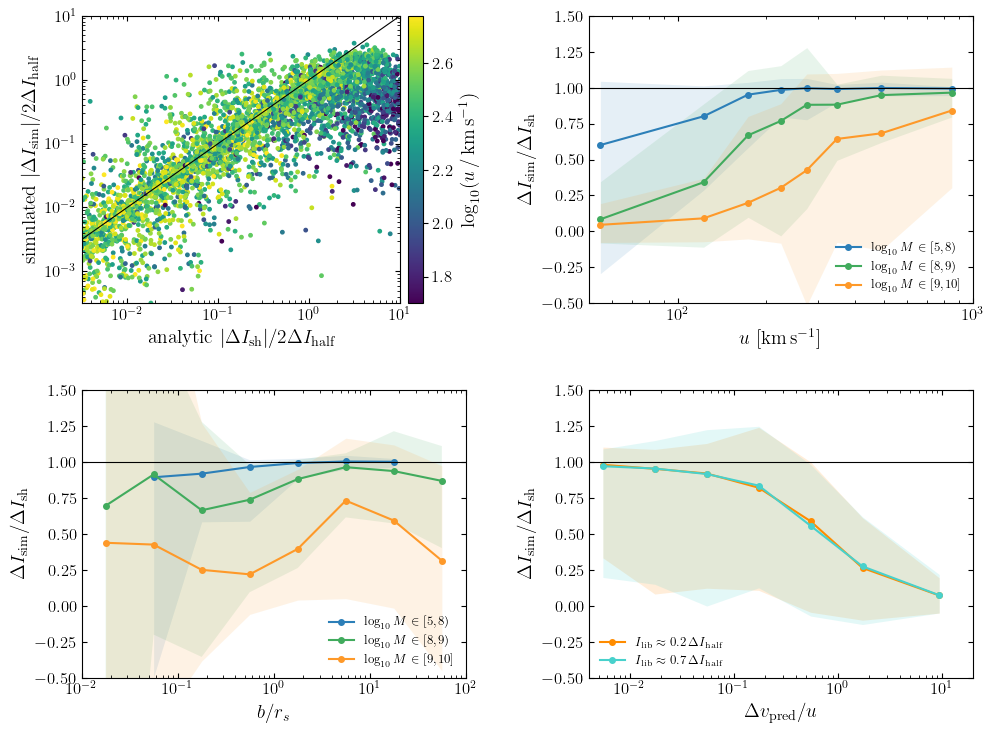

In [18]:
# Fig. 5: accuracy of the analytic (impulse) kick
fig, axs = plt.subplots(2, 2, figsize=(11.5, 8.6), gridspec_kw={'wspace': 0.32, 'hspace': 0.3}); a1, a2, a3, a4 = axs.ravel()
s = s_of[DV[0]]; s0 = s & (np.abs(R['x_pred']) > 0.01)
sc = a1.scatter(np.abs(R['x_pred'][s]), np.abs(R['x_sim'][s]), c=np.log10(R['u'][s]), s=6, cmap='viridis', vmin=np.log10(50), vmax=np.log10(600), rasterized=True)
a1.plot([1e-4, 100], [1e-4, 100], 'k-', lw=0.8); a1.set_xscale('log'); a1.set_yscale('log'); a1.set_xlim(*XLIM); a1.set_ylim(XLIM[0]/10, XLIM[1]); style(a1)
a1.set_xlabel(r'analytic $|\Delta I_{\rm sh}|/2\Delta I_{\rm half}$'); a1.set_ylabel(r'simulated $|\Delta I_{\rm sim}|/2\Delta I_{\rm half}$')
fig.colorbar(sc, ax=a1, pad=0.02).set_label(r'$\log_{10}(u\,/\,{\rm km\,s^{-1}})$')
lb, hb = np.log10(B_RANGE[0]), np.log10(B_RANGE[1]); nb_ = max(int(round(2*(hb - lb))) + 1, 3)
for ax, var, edges, xl, xlim in [(a2, R['u'], np.array([30, 100, 150, 200, 250, 300, 400, 600, 1200, 5000]), r'$u\ [{\rm km\,s^{-1}}]$', (50, 1000)),
                                 (a3, brs, np.logspace(lb, hb + 1e-3, nb_), r'$b/r_s$', None)]:
    for (lo, hi), col in zip(MB, MC):
        t = curve(s0 & (R['logM'] >= lo) & (R['logM'] < hi), var, edges)
        if t.size: ax.plot(t[0], t[1], '-o', ms=4, color=col, label=mlab(lo, hi)); ax.fill_between(t[0], t[2], t[3], color=col, alpha=0.12, lw=0)
    if xlim is None:      # b/r_s is drawn from a much wider range (B_RANGE) than the curves cover: show whole decades around the data
        xd = np.concatenate([ln.get_xdata() for ln in ax.lines]); xlim = (10**np.floor(np.log10(xd.min())), 10**np.ceil(np.log10(xd.max())))
    ax.axhline(1, color='k', lw=0.8); ax.set_xscale('log'); ax.set_xlim(*xlim); ax.set_ylim(-0.5, 1.5); style(ax)
    ax.set_xlabel(xl); ax.set_ylabel(r'$\Delta I_{\rm sim}/\Delta I_{\rm sh}$'); ax.legend(loc='lower right', frameon=False, fontsize=9)
q = 2*G*10**R['logM']*R['b']/(R['u']*(R['b']**2 + R['rs']**2))/R['u']          # predicted |Delta v| / u
for k, v in enumerate(DV):
    t = curve(s_of[v] & (np.abs(R['x_pred']) > 0.01), q, np.array([0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 30]))
    if t.size: a4.plot(t[0], t[1], '-o', ms=4, color=AC[k], label=r'$I_{\rm lib}\approx%s\,\Delta I_{\rm half}$' % AL[k]); a4.fill_between(t[0], t[2], t[3], color=AC[k], alpha=0.15, lw=0)
a4.axhline(1, color='k', lw=0.8); a4.set_xscale('log'); a4.set_xlim(4e-3, 20); a4.set_ylim(-0.5, 1.5); style(a4)
a4.set_xlabel(r'$\Delta v_{\rm pred}/u$'); a4.set_ylabel(r'$\Delta I_{\rm sim}/\Delta I_{\rm sh}$'); a4.legend(loc='lower left', frameon=False, fontsize=9)
if SAVE_PAPER: plt.savefig(os.path.join(FIGDIR, 'impulse_accuracy.pdf'), dpi=400, bbox_inches='tight')
plt.show()

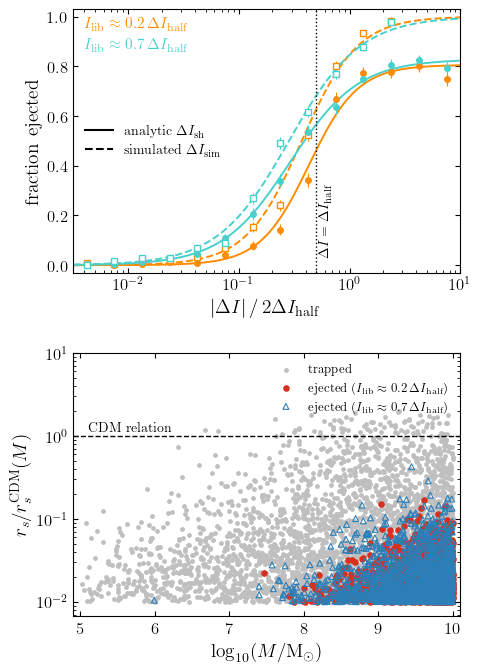

In [19]:
# calibration of the ejection threshold
bins_x = np.logspace(X_LOGRANGE[0], X_LOGRANGE[1], 15); xc_x = np.sqrt(bins_x[1:]*bins_x[:-1]); xs_fit = np.logspace(X_LOGRANGE[0], X_LOGRANGE[1], 300)
def frac(x, y):
    """Fraction ejected (and its binomial error) in bins of |x|."""
    n = np.histogram(x, bins_x)[0]; ne = np.histogram(x[y], bins_x)[0]; ok = n > 4; f = ne[ok]/np.maximum(n[ok], 1)
    return xc_x[ok], f, np.sqrt(f*(1 - f)/np.maximum(n[ok], 1) + 1e-4)
def plot_fit(ax, p, **kw):
    if np.all(np.isfinite(p)): ax.plot(xs_fit, logistic(xs_fit, p), **kw)

# one column of two panels, each with the height/width of the panels in the paper's other single-column figures
# (e.g. diffusion_results: 2 x 1 panels, figsize (5, 7), hspace 0.05 -> 0.68)
PANEL_ASPECT = 0.68
fig, (b1, b2) = plt.subplots(2, 1, figsize=(5, 7.9), gridspec_kw={'hspace': 0.3})
for ax in (b1, b2): ax.set_box_aspect(PANEL_ASPECT)
for k, v in enumerate(DV):
    s = s_of[v]
    for kick, ls, mk in [('x_pred', '-', 'o'), ('x_sim', '--', 's')]:
        xx, f, err = frac(np.abs(R[kick][s]), R['ejected'][s])
        b1.errorbar(xx, f, yerr=err, fmt=mk, ms=4, color=AC[k], mfc='white' if kick == 'x_sim' else AC[k], lw=0.8, capsize=0); plot_fit(b1, fits[(v, kick)], ls=ls, color=AC[k], lw=1.4)
    b1.text(0.03, 0.93 - 0.08*k, r'$I_{\rm lib}\approx%s\,\Delta I_{\rm half}$' % AL[k], transform=b1.transAxes, color=AC[k], fontsize=11)
b1.axvline(0.5, color='k', ls=':', lw=1); b1.text(0.53, 0.03, r'$\Delta I=\Delta I_{\rm half}$', fontsize=10, rotation=90, va='bottom')
b1.plot([], [], 'k-', label=r'analytic $\Delta I_{\rm sh}$'); b1.plot([], [], 'k--', label=r'simulated $\Delta I_{\rm sim}$'); b1.legend(loc='center left', frameon=False, fontsize=10)
b1.set_xscale('log'); b1.set_xlim(*XLIM); b1.set_ylim(-0.03, 1.03); style(b1)
b1.set_xlabel(r'$|\Delta I|\,/\,2\Delta I_{\rm half}$'); b1.set_ylabel('fraction ejected')
for k, v in enumerate(DV):
    s = s_of[v]; e = R['ejected'][s]; lab = r'ejected ($I_{\rm lib}\approx%s\,\Delta I_{\rm half}$)' % AL[k]
    if k == 0:
        b2.scatter(R['logM'][s][~e], fc_all[s][~e], s=6, c='0.75', rasterized=True, label='trapped')
        b2.scatter(R['logM'][s][e], fc_all[s][e], s=14, c='#d7301f', rasterized=True, label=lab)
    else:
        b2.scatter(R['logM'][s][e], fc_all[s][e], s=18, facecolors='none', edgecolors=['#2c7fb8', 'tab:green', 'tab:purple', 'k', 'tab:brown'][min(k - 1, 4)],
                   marker=['^', 's', 'D', 'v', 'P'][min(k - 1, 4)], lw=0.8, rasterized=True, label=lab)
b2.axhline(1.0, color='k', ls='--', lw=1); b2.text(LOGM_RANGE[0] + 0.1, 1.1, 'CDM relation', fontsize=10)
b2.set_yscale('log'); b2.set_xlim(LOGM_RANGE[0] - 0.1, LOGM_RANGE[1] + 0.1); b2.set_ylim(FC_RANGE[0]/1.5, FC_RANGE[1]*5); style(b2)
b2.set_xlabel(r'$\log_{10}(M/{\rm M}_\odot)$'); b2.set_ylabel(r'$r_s/r_s^{\rm CDM}(M)$'); b2.legend(loc='upper right', frameon=False, fontsize=9)
if SAVE_PAPER: plt.savefig(os.path.join(FIGDIR, 'ejection_threshold.pdf'), dpi=400, bbox_inches='tight')
plt.show()

In [20]:
# tables for Section 3.3: accuracy of the kick, timing of the measurement, ejection fits, large-b sweep
def stats(m):
    g = m & (np.abs(R['x_pred']) > 0.01)
    if g.sum() < 3: return m.sum(), np.nan, np.nan, np.nan, np.nan
    rat = R['x_sim'][g]/R['x_pred'][g]
    lr, lp = np.log10(np.abs(R['x_sim'][g]) + 1e-12), np.log10(np.abs(R['x_pred'][g]))
    return m.sum(), np.median(rat), np.percentile(rat, 16), np.percentile(rat, 84), 1 - np.sum((lr - lp)**2)/np.sum((lr - lr.mean())**2)
acc = lambda m: np.mean((np.abs(R['x_pred'][m]) > 0.5) == R['ejected'][m]) if m.any() else np.nan
near = fc_all > 0.5
rows = [(r'$%g$--$%g$' % (lo, mtop(hi)), lambda s, lo=lo, hi=hi: s & (R['logM'] >= lo) & (R['logM'] < hi)) for lo, hi in MB]
rows += [(r'near-CDM ($r_s>0.5\,r_s^{\rm CDM}$)', lambda s: s & near), ('all', lambda s: s)]
nn = len(DV)
cap_near = (r" The near-CDM encounters are all weak ($|\Delta I_{\rm sh}|<%.2f\times2\Delta I_{\rm half}$), so $R^2$ is not meaningful there and is omitted." % np.abs(R['x_pred'][near]).max()) if near.any() else ''
L = [r"\begin{table}", r"\centering",
     r"\caption{Accuracy of the impulse model across the encounter sweep (Section~\ref{sec:sweep}), for the star with libration amplitude %s\,$\Delta I_{\rm half}$. Columns give the number of encounters $N$, the median and 16th--84th percentiles of the ratio of simulated to analytic kick (for $|\Delta I_{\rm sh}|>0.01\times2\Delta I_{\rm half}$), and the coefficient of determination $R^2$ of $\log_{10}|\Delta I|$. The last %s give the fraction of encounters whose outcome (ejected or trapped) is correctly classified by $|\Delta I_{\rm sh}|>\Delta I_{\rm half}$, for libration amplitude%s %s\,$\Delta I_{\rm half}$.%s}"
     % (AL[0], 'column' if nn == 1 else 'two columns' if nn == 2 else '%d columns' % nn, '' if nn == 1 else 's', ALS, cap_near),
     r"\label{tab:calibration}", r"\begin{tabular}{l%s}" % ('c'*(3 + nn)), r"\hline",
     r"$\log_{10}(M/{\rm M}_\odot)$ & $N$ & $\Delta I_{\rm sim}/\Delta I_{\rm sh}$ & $R^2$ & \multicolumn{%d}{c}{outcome correct} \\" % nn, r" & & & & %s \\" % ' & '.join(AL), r"\hline"]
for lab, sel in rows:
    N, med, q16, q84, r2 = stats(sel(s_of[DV[0]]))
    L.append(r"%s & %d & $%s_{%s}^{%s}$ & %s%s \\" % (lab, N, fmt(med), fmt(q16), fmt(q84), '--' if 'near' in lab else fmt(r2), ''.join(' & ' + fmt(acc(sel(s_of[v]))) for v in DV)))
write_tex('table_calibration.tex', L)

tlab = {'x_sim_f2': r'$2(b+r_s)/u$', 'x_sim': r'$4(b+r_s)/u$ (default)', 'x_sim_f8': r'$8(b+r_s)/u$', 'x_sim_25': r'25\,Myr (fixed)'}
def med_ratio(key, v):
    g = s_of[v] & (np.abs(R['x_pred']) > 0.01); return np.median(R[key][g]/R['x_pred'][g]) if g.any() else np.nan
MED = {k: [med_ratio(k, v) for v in DV] for k in tlab}; X50T = {k: [fit_logistic(R[k][s_of[v]], R['ejected'][s_of[v]])[0] for v in DV] for k in tlab}
def spread(D):
    a = np.array(list(D.values())); return np.nanmax((a.max(0) - a.min(0))/np.abs(a.mean(0)))
sp, sp2 = spread(MED), spread(X50T)
pct = int(np.ceil(max(sp if np.isfinite(sp) else 0, sp2 if np.isfinite(sp2) else 0)*100/5)*5)
T = [r"\begin{table}", r"\centering",
     r"\caption{Sensitivity of the simulated kick to the time at which it is evaluated after closest approach. For each choice we give the median ratio of simulated to analytic kick ($|\Delta I_{\rm sh}|>0.01\times2\Delta I_{\rm half}$) and the threshold $x_{50}$ (in units of $2\Delta I_{\rm half}$) of a logistic fit of the ejection probability to the \emph{simulated} kick, for libration amplitude%s %s\,$\Delta I_{\rm half}$. Neither changes by more than about %d per cent across these choices; the ejection outcome itself is judged $\geq100$\,Myr after the encounter and does not depend on it at all.}"
     % ('' if nn == 1 else 's', ALS, pct),
     r"\label{tab:timing}", r"\begin{tabular}{l%s}" % ('c'*(2*nn)), r"\hline",
     r"measurement time & \multicolumn{%d}{c}{median ratio} & \multicolumn{%d}{c}{$x_{50}$ (simulated kick)} \\" % (nn, nn), r" & %s & %s \\" % (' & '.join(AL), ' & '.join(AL)), r"\hline"]
for key in tlab: T.append(r"%s %s %s \\" % (tlab[key], ''.join(' & ' + fmt(m) for m in MED[key]), ''.join(' & ' + fmt(x) for x in X50T[key])))
write_tex('table_timing.tex', T)

E = [r"\begin{table}", r"\centering",
     r"\caption{Calibration of the ejection threshold. A logistic function $P_{\rm ej}(x)=p_{\max}/\{1+\exp[-\ln(x/x_{50})/w]\}$ is fitted to the ejection outcomes of the sweep, with $x=|\Delta I|/2\Delta I_{\rm half}$ taken either from the analytic kick $\Delta I_{\rm sh}$ or from the simulated kick $\Delta I_{\rm sim}$. $A$ is the fraction of encounters whose outcome is correctly classified by $x>x_{50}$ and AUC is the area under the ROC curve of $x$ as a classifier. The final column is the accuracy of the full pendulum criterion (Eq.~\ref{eq:pendulum}) evaluated with the simulated kick and the star's pre-encounter $(I_0,\phi_0)$. Entries marked -- could not be fitted because fewer than five encounters were ejected (or trapped).}",
     r"\label{tab:ejection_fits}", r"\begin{tabular}{llccccccc}", r"\hline", r"$I_{\rm lib}/\Delta I_{\rm half}$ & kick & $x_{50}$ & $w$ & $p_{\max}$ & $A$ & AUC & $A(x>0.5)$ & pendulum \\", r"\hline"]
for v, al in zip(DV, AL):
    s = s_of[v]; y = R['ejected'][s]; pend = np.mean(pendulum_ejected(R['I0'][s], R['phi0'][s], R['x_sim'][s]) == y)
    for k, name in [('x_pred', 'analytic'), ('x_sim', 'simulated')]:
        x50, w_, pm = fits[(v, k)]; x = R[k][s]
        E.append(r"%s & %s & %s & %s & %s & %s & %s & %s & %s \\" % (al if k == 'x_pred' else '', name, fmt(x50), fmt(w_), fmt(pm), fmt(np.mean((np.abs(x) > x50) == y)) if np.isfinite(x50) else '--',
                                                                fmt(auc(x, y)), fmt(np.mean((np.abs(x) > .5) == y)), fmt(pend) if k == 'x_sim' else '--'))
    if v != DV[-1]: E.append(r"\hline")
write_tex('table_ejection_fits.tex', E)

if 'RB' in globals():
    blo, bhi = B_LB; mlo, mhi = round(float(LOGM_LB[0]), 1), round(float(LOGM_LB[1]), 1); cut = mlo + 0.5*(mhi - mlo)
    edges = np.geomspace(blo, bhi, 4)*np.array([1, 1, 1, 1.001])
    DVB = sorted(set(RB['dv']))
    LB = [r"\begin{table}", r"\centering",
          r"\caption{Supplementary sweep at large impact parameter ($%.3g\le b\le%.3g$\,kpc, $10^{%g}\le M/{\rm M}_\odot\le10^{%g}$, all other settings as in Section~\ref{sec:sweep}; %s encounters for the libration amplitude%s). For each range of $b$ we give the number of encounters $N$, the number ejected, the largest analytic kick in units of $2\Delta I_{\rm half}$, the median ratio of simulated to analytic kick for $M\geq10^{%.1f}\,{\rm M}_\odot$, and the fraction of outcomes correctly classified by $|\Delta I_{\rm sh}|>\Delta I_{\rm half}$.}"
          % (blo, bhi, mlo, mhi, nice_list([str(int((RB['dv'] == v).sum())) for v in DVB]), ' (in the same order)' if len(DVB) > 1 else '', cut),
          r"\label{tab:largeb}", r"\begin{tabular}{llccccc}", r"\hline", r"$I_{\rm lib}/\Delta I_{\rm half}$ & $b$ [kpc] & $N$ & ejected & $\max x_{\rm pred}$ & $\Delta I_{\rm sim}/\Delta I_{\rm sh}$ & correct \\", r"\hline"]
    for i, v in enumerate(DVB):
        s = RB['dv'] == v; al = '%.1f' % RB['amp'][s][0]
        for j, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
            m = s & (RB['b'] >= lo) & (RB['b'] < hi); x = np.abs(RB['x_pred'][m]); y = RB['ejected'][m]; g = m & (RB['logM'] >= cut) & (np.abs(RB['x_pred']) > 0.01)
            LB.append(r"%s & %.3g--%.3g & %d & %d & %s & %s & %s \\" % (al if j == 0 else '', lo, min(hi, bhi), m.sum(), y.sum(), fmt(x.max()) if m.any() else '--',
                                                                       fmt(np.median(RB['x_sim'][g]/RB['x_pred'][g])) if g.any() else '--', fmt(np.mean((x > .5) == y)) if m.any() else '--'))
        if i < len(DVB) - 1: LB.append(r"\hline")
    write_tex('table_largeb.tex', LB)

\begin{table}
\centering
\caption{Accuracy of the impulse model across the encounter sweep (Section~\ref{sec:sweep}), for the star with libration amplitude 0.2\,$\Delta I_{\rm half}$. Columns give the number of encounters $N$, the median and 16th--84th percentiles of the ratio of simulated to analytic kick (for $|\Delta I_{\rm sh}|>0.01\times2\Delta I_{\rm half}$), and the coefficient of determination $R^2$ of $\log_{10}|\Delta I|$. The last two columns give the fraction of encounters whose outcome (ejected or trapped) is correctly classified by $|\Delta I_{\rm sh}|>\Delta I_{\rm half}$, for libration amplitudes 0.2 and 0.7\,$\Delta I_{\rm half}$. The near-CDM encounters are all weak ($|\Delta I_{\rm sh}|<0.26\times2\Delta I_{\rm half}$), so $R^2$ is not meaningful there and is omitted.}
\label{tab:calibration}
\begin{tabular}{lccccc}
\hline
$\log_{10}(M/{\rm M}_\odot)$ & $N$ & $\Delta I_{\rm sim}/\Delta I_{\rm sh}$ & $R^2$ & \multicolumn{2}{c}{outcome correct} \\
 & & & & 0.2 & 0.7 \\

\begin{table}
\centering
\caption{Sensitivity of the simulated kick to the time at which it is evaluated after closest approach. For each choice we give the median ratio of simulated to analytic kick ($|\Delta I_{\rm sh}|>0.01\times2\Delta I_{\rm half}$) and the threshold $x_{50}$ (in units of $2\Delta I_{\rm half}$) of a logistic fit of the ejection probability to the \emph{simulated} kick, for libration amplitudes 0.2 and 0.7\,$\Delta I_{\rm half}$. Neither changes by more than about 5 per cent across these choices; the ejection outcome itself is judged $\geq100$\,Myr after the encounter and does not depend on it at all.}
\label{tab:timing}
\begin{tabular}{lcccc}
\hline
measurement time & \multicolumn{2}{c}{median ratio} & \multicolumn{2}{c}{$x_{50}$ (simulated kick)} \\
 & 0.2 & 0.7 & 0.2 & 0.7 \\
\hline
$2(b+r_s)/u$  & 0.65 & 0.63  & 0.37 & 0.28 \\
$4(b+r_s)/u$ (default)  & 0.63 & 0.62  & 0.37 & 0.28 \\
$8(b+r_s)/u$  & 0.62 & 0.61  & 0.36 & 0.28 \\
25\,Myr (fixed)  & 0.64 & 0.62  &

In [21]:
# headline statistics of the ejection calibration (written to headline_33_34.txt and .json)
BOOTSTRAP = True                                     # 95 per cent intervals on the accuracy and AUC (about a minute)
rng_boot = np.random.default_rng(0)                  # separate from the sweep's rng, so that re-running the sweep is unaffected
def boot(f, n, nb=1000):
    return np.nanpercentile([f(rng_boot.integers(0, n, n)) for _ in range(nb)], [2.5, 97.5])
H = {}
hl = ['Headline accuracy of the analytic (impulse) model, from %s' % os.path.basename(OUTFILE), '']
for v, al in zip(DV, AL):
    s = np.where(s_of[v])[0]; y = R['ejected'][s]; xp = np.abs(R['x_pred'][s]); xm = np.abs(R['x_sim'][s]); x50, w_, pm = fits[(v, 'x_pred')]
    hd = dict(amp=float(al), N=int(len(s)), base_rate_ejected=float(y.mean()), majority_accuracy=float(max(y.mean(), 1 - y.mean())), x50=float(x50), w=float(w_), p_max=float(pm))
    if np.isfinite(x50):
        a_f = lambda i: np.mean((xp[i] > x50) == y[i]); u_f = lambda i: auc(xp[i], y[i]); idx = np.arange(len(s))
        hd.update(accuracy=float(a_f(idx)), auc=float(u_f(idx)), accuracy_analytic_0p5=float(np.mean((xp > 0.5) == y)))
        if BOOTSTRAP: hd.update(accuracy_ci95=[float(t) for t in boot(a_f, len(s))], auc_ci95=[float(t) for t in boot(u_f, len(s), 400)])
        ths = np.logspace(-2, 1, 400)
        hd['best_single_threshold_accuracy'] = dict(predicted=float(max(np.mean((xp > t) == y) for t in ths)), measured=float(max(np.mean((xm > t) == y) for t in ths)))
        xg = np.logspace(-3, 1.5, 4000); P = logistic(xg, (x50, w_, pm))
        hd['x10_x90'] = [float(xg[np.argmax(P > 0.1)]) if (P > 0.1).any() else np.nan, float(xg[np.argmax(P > 0.9)]) if (P > 0.9).any() else np.nan]
        err = (xp > x50) != y; hd['errors_within_factor2_of_x50'] = float(np.mean((xp[err] > x50/2) & (xp[err] < 2*x50))) if err.any() else np.nan
        try:
            from sklearn.ensemble import HistGradientBoostingClassifier as HG
            from sklearn.model_selection import cross_val_predict, StratifiedKFold
            X = np.column_stack([np.log10(xp + 1e-6), np.log10(xm + 1e-6), R['I0'][s], np.cos(R['phi0'][s]), np.sin(R['phi0'][s]), R['logM'][s], np.log10(R['u'][s]), np.log10(R['b'][s]/R['rs'][s]), np.log10(R['rs'][s])])
            p = cross_val_predict(HG(max_iter=200, learning_rate=0.05), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0), method='predict_proba')[:, 1]
            hd['cv_ceiling'] = dict(accuracy=float(np.mean((p > .5) == y)), auc=float(auc(p, y)))
        except Exception as ex: hd['cv_ceiling'] = 'not computed (%s)' % type(ex).__name__
    gk = (xp > 0.01); r = xm[gk]/xp[gk]
    if gk.any(): hd.update(kick_median_ratio=float(np.median(r)), kick_within_factor2=float(np.mean((r > .5) & (r < 2))), mean_square_kick_ratio=float(np.sum(xm**2)/np.sum(xp**2)))
    H['amp_%s' % al] = hd
    hl += ['libration amplitude %s dI_half (N = %d, ejected fraction %.2f, majority-class accuracy %.2f):' % (al, hd['N'], hd['base_rate_ejected'], hd['majority_accuracy'])]
    if 'accuracy' in hd:
        ci = lambda k: ' (95%% CI %.3f-%.3f)' % tuple(hd[k]) if k in hd else ''
        hl += ['   calibrated accuracy %.3f%s, AUC %.3f%s, x50 = %.2f, analytic x>0.5 accuracy %.3f' % (hd['accuracy'], ci('accuracy_ci95'), hd['auc'], ci('auc_ci95'), x50, hd['accuracy_analytic_0p5']),
               '   best single threshold: predicted %.3f, measured %.3f;  10-90%% transition x = %.2f-%.2f;  errors within a factor 2 of x50: %.2f'
               % (hd['best_single_threshold_accuracy']['predicted'], hd['best_single_threshold_accuracy']['measured'], *hd['x10_x90'], hd['errors_within_factor2_of_x50']),
               '   cross-validated ceiling (gradient boosting, all inputs): %s' % (('accuracy %.3f, AUC %.3f' % (hd['cv_ceiling']['accuracy'], hd['cv_ceiling']['auc'])) if isinstance(hd['cv_ceiling'], dict) else hd['cv_ceiling'])]
    else: hl += ['   too few ejected / trapped encounters to fit the logistic (fewer than 5 of one class)']
    if 'kick_median_ratio' in hd:
        hl += ['   kick: median measured/predicted %.2f, within a factor 2: %.2f, sum(x_sim^2)/sum(x_pred^2) = %.2f (resampled sweep, not a population value)' % (hd['kick_median_ratio'], hd['kick_within_factor2'], hd['mean_square_kick_ratio'])]
    hl.append('')
if SAVE_TABLES:
    os.makedirs(TABDIR, exist_ok=True); open(os.path.join(TABDIR, 'headline_33_34.txt'), 'w').write("\n".join(hl)); json.dump(H, open(os.path.join(TABDIR, 'headline_33_34.json'), 'w'), indent=1)
print("\n".join(hl))

Headline accuracy of the analytic (impulse) model, from ejection_calibration_hamilton_host.npz

libration amplitude 0.2 dI_half (N = 4933, ejected fraction 0.31, majority-class accuracy 0.69):
   calibrated accuracy 0.865 (95% CI 0.855-0.875), AUC 0.917 (95% CI 0.909-0.924), x50 = 0.43, analytic x>0.5 accuracy 0.868
   best single threshold: predicted 0.869, measured 0.877;  10-90% transition x = 0.16-nan;  errors within a factor 2 of x50: 0.40
   cross-validated ceiling (gradient boosting, all inputs): accuracy 0.896, AUC 0.962
   kick: median measured/predicted 0.74, within a factor 2: 0.57, sum(x_sim^2)/sum(x_pred^2) = 0.08 (resampled sweep, not a population value)

libration amplitude 0.7 dI_half (N = 4951, ejected fraction 0.36, majority-class accuracy 0.64):
   calibrated accuracy 0.829 (95% CI 0.817-0.841), AUC 0.896 (95% CI 0.888-0.904), x50 = 0.29, analytic x>0.5 accuracy 0.823
   best single threshold: predicted 0.832, measured 0.836;  10-90% transition x = 0.07-nan;  errors 